# Atobb vs TTLJ XGBoost Training and ONNX Export

This notebook trains a first-pass XGBoost classifier using the `Training_Tree` produced by `AtobbMLTree`.

- Signal: `TTToHcToWAToBB-MHc100_MA60.root` by default
- Background: `TTLJ_powheg.root` by default
- Main weight: `weight_train`
- Output model: `xgboost_atobb_ttlJ.onnx`

Before running, check that the ROOT paths below match your actual output directory.


## 1. Imports

Run this in the `MLHEP` kernel/environment where `ROOT`, `xgboost`, `onnxmltools`, and `skl2onnx` are installed.


In [1]:
import os
import json
import pickle
import numpy as np
import pandas as pd
import ROOT
import xgboost as xgb
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import roc_curve, auc, accuracy_score, confusion_matrix

import onnx
from onnxmltools.convert import convert_xgboost as convert_xgboost_booster
from skl2onnx.common.data_types import FloatTensorType

np.random.seed(42)


## 2. Input ROOT files

Change these paths if your files are somewhere else.


In [3]:
BASE_DIR = "/data9/Users/eunsu/SKNanoOutput/AtobbMLTree/2024"

SIG_FILES = [
    f"{BASE_DIR}/TTToHcToWAToBB-MHc130_MA90_SingleLepFilter.root",
]

#BKG_FILES = [
#    f"{BASE_DIR}/TTToHcToWAToBB-MHc130_MA90_SingleLepFilter.root",
#]

BKG_FILES = [
    f"{BASE_DIR}/TTLJ_powheg.root",
]

TREE_NAME = "Training_Tree"
MODEL_DIR = "/data9/Users/eunsu/MachineLearning/models"
os.makedirs(MODEL_DIR, exist_ok=True)

MODEL_NAME = "xgboost_atobb_ttlJ"

ONNX_PATH = f"{MODEL_DIR}/{MODEL_NAME}.onnx"
FEATURE_JSON_PATH = f"{MODEL_DIR}/{MODEL_NAME}_features.json"
SCALER_JSON_PATH = f"{MODEL_DIR}/{MODEL_NAME}_scaler.json"
SCALER_PICKLE_PATH = f"{MODEL_DIR}/{MODEL_NAME}_scaler.pkl"

# Background statistics test.
# Change this to 10000, 20000, 50000, 100000, or None.
N_BKG = 100000

# Booster scan. Later, choose one value and rerun for the final model.
NUM_BOOST_ROUND = 500  # Try 20, 50, 100, 200, 300

# Preprocessing choice: "standard", "minmax", or None
SCALER_TYPE = "standard"

print("Signal files:")
for p in SIG_FILES:
    print("  ", p, os.path.exists(p))
print("Background files:")
for p in BKG_FILES:
    print("  ", p, os.path.exists(p))


Signal files:
   /data9/Users/eunsu/SKNanoOutput/AtobbMLTree/2024/TTToHcToWAToBB-MHc130_MA90_SingleLepFilter.root True
Background files:
   /data9/Users/eunsu/SKNanoOutput/AtobbMLTree/2024/TTLJ_powheg.root True


## 3. Load ROOT tree into pandas

This function reads only the branches we need, which is faster and safer than reading everything.


In [4]:
def read_training_tree(files, tree_name="Training_Tree", branches=None):
    dfs = []
    for path in files:
        if not os.path.exists(path):
            raise FileNotFoundError(path)
        f = ROOT.TFile.Open(path, "READ")
        if not f or f.IsZombie():
            raise RuntimeError(f"Cannot open ROOT file: {path}")
        tree = f.Get(tree_name)
        if not tree:
            raise RuntimeError(f"Cannot find tree '{tree_name}' in {path}")
        rdf = ROOT.RDataFrame(tree)
        if branches is None:
            arr = rdf.AsNumpy()
        else:
            arr = rdf.AsNumpy(branches)
        df = pd.DataFrame(arr)
        df["source_file"] = os.path.basename(path)
        dfs.append(df)
        f.Close()
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()


## 4. Feature list

First-pass feature set. These are physics-motivated variables from `AtobbMLTree`: jet activity, b-tag topology, bb-pair masses, and ttbar reconstruction variables.

Do **not** include `label`, `weight_*`, or `source_file` as ML inputs.


In [5]:
def add_high_level_features(df):
    out = df.copy()

    bb_mass_cols = ["bb_mass_01", "bb_mass_02", "bb_mass_12"]
    bb_dr_cols = ["bb_dr_01", "bb_dr_02", "bb_dr_12"]

    # A -> bb pair summary
    out["bb_mass_min"] = out[bb_mass_cols].min(axis=1)
    out["bb_mass_max"] = out[bb_mass_cols].max(axis=1)
    out["bb_mass_mean"] = out[bb_mass_cols].mean(axis=1)

    # For current single mass point MA=60
    out["bb_mass_closest_MA60"] = np.min(
        np.abs(out[bb_mass_cols].to_numpy(dtype=float) - 60.0),
        axis=1
    )

    out["bb_dr_min"] = out[bb_dr_cols].min(axis=1)
    out["bb_dr_max"] = out[bb_dr_cols].max(axis=1)
    out["bb_dr_mean"] = out[bb_dr_cols].mean(axis=1)

    return out



In [6]:
BASE_FEATURES = [
    # event activity
    "HT", "ST", "MET_Pt",

    # multiplicity
    "nJets",
    "nJets_for_count",
    "nBJets",

    # lepton
    "Lepton0_Pt",
    "Lepton0_Eta",

    # A -> bb candidate from all b-tagged jet pairs
    "A_mass_best",
    "A_dr_best",
    "A_pt_best",
    "A_bscore_sum_best",
    "A_bscore_min_best",

    # all bb-pair summaries
    "bb_mass_min_all",
    "bb_mass_max_all",
    "bb_mass_at_min_dr",
    "bb_mass_closest_MA60_all",
    "bb_mass_spread_all",
    "bb_dr_min_all",
    "bb_dr_max_all",

    # b-tag topology
    "bscore_max",
    "bscore_2nd",
    "bscore_3rd",
    "bscore_sum",
    "bscore_sum_top4",

    # ttbar reconstruction
    "best_chi2",
    "had_W_mass",
    "had_top_mass",
    "lep_W_mass",
    "lep_top_mass",

    "A_pt_over_mass",
    "A_eta_abs",
    "A_mass_dr",
    "A_pt_balance_best",

]
# FEATURES = BASE_FEATURES + ADDED_FEATURES
FEATURES_TOP = [
    "bb_mass_closest_MA60_all",
    "bb_dr_min_all",
    "bb_mass_min_all",
    "A_mass_best",
    "bb_mass_at_min_dr",
#    "nBJets",
    "A_dr_best",
    "bb_mass_max_all",
    "ST",
    "bb_dr_max_all",
    "A_pt_over_mass",
    "A_eta_abs",
    "A_mass_dr",
    "A_pt_balance_best",
    

]

FEATURES_NO_BSCORE = [
    f for f in BASE_FEATURES
    if not f.startswith("bscore") and "bscore" not in f
]

# 여기서 학습에 쓸 feature set 선택
# FEATURES = FEATURES_TOP
FEATURES = BASE_FEATURES
# FEATURES = FEATURES_NO_BSCORE

WEIGHT_COL = "weight_train"
LABEL_COL = "label"

# ROOT에서 읽을 branch는 넉넉하게 BASE_FEATURES 기준으로 읽기
BRANCHES_TO_READ = sorted(set(BASE_FEATURES + [WEIGHT_COL, "weight_nominal", LABEL_COL]))

print(f"Number of features = {len(FEATURES)}")
print(FEATURES)
print(f"Number of ROOT branches to read = {len(BRANCHES_TO_READ)}")
print(BRANCHES_TO_READ)


Number of features = 34
['HT', 'ST', 'MET_Pt', 'nJets', 'nJets_for_count', 'nBJets', 'Lepton0_Pt', 'Lepton0_Eta', 'A_mass_best', 'A_dr_best', 'A_pt_best', 'A_bscore_sum_best', 'A_bscore_min_best', 'bb_mass_min_all', 'bb_mass_max_all', 'bb_mass_at_min_dr', 'bb_mass_closest_MA60_all', 'bb_mass_spread_all', 'bb_dr_min_all', 'bb_dr_max_all', 'bscore_max', 'bscore_2nd', 'bscore_3rd', 'bscore_sum', 'bscore_sum_top4', 'best_chi2', 'had_W_mass', 'had_top_mass', 'lep_W_mass', 'lep_top_mass', 'A_pt_over_mass', 'A_eta_abs', 'A_mass_dr', 'A_pt_balance_best']
Number of ROOT branches to read = 37
['A_bscore_min_best', 'A_bscore_sum_best', 'A_dr_best', 'A_eta_abs', 'A_mass_best', 'A_mass_dr', 'A_pt_balance_best', 'A_pt_best', 'A_pt_over_mass', 'HT', 'Lepton0_Eta', 'Lepton0_Pt', 'MET_Pt', 'ST', 'bb_dr_max_all', 'bb_dr_min_all', 'bb_mass_at_min_dr', 'bb_mass_closest_MA60_all', 'bb_mass_max_all', 'bb_mass_min_all', 'bb_mass_spread_all', 'best_chi2', 'bscore_2nd', 'bscore_3rd', 'bscore_max', 'bscore_sum'

## 5. Read signal and background samples

For this notebook, we override the label explicitly to avoid relying on sample-name parsing.


In [7]:
df_sig = read_training_tree(SIG_FILES, TREE_NAME, branches=BRANCHES_TO_READ)
df_bkg = read_training_tree(BKG_FILES, TREE_NAME, branches=BRANCHES_TO_READ)

df_sig[LABEL_COL] = 1
df_bkg[LABEL_COL] = 0

# df_sig = add_high_level_features(df_sig)
# df_bkg = add_high_level_features(df_bkg)

print("Before background limit:")
print("  signal entries:", len(df_sig))
print("  bkg entries   :", len(df_bkg))

if N_BKG is not None and len(df_bkg) > N_BKG:
    df_bkg = df_bkg.sample(n=N_BKG, random_state=42).reset_index(drop=True)

print("After background limit:")
print("  signal entries:", len(df_sig))
print("  bkg entries   :", len(df_bkg))

df_sig.head()


Before background limit:
  signal entries: 15772
  bkg entries   : 2245142
After background limit:
  signal entries: 15772
  bkg entries   : 100000


,A_bscore_min_best,A_bscore_sum_best,A_dr_best,A_eta_abs,A_mass_best,A_mass_dr,A_pt_balance_best,A_pt_best,A_pt_over_mass,HT,...,had_top_mass,label,lep_W_mass,lep_top_mass,nBJets,nJets,nJets_for_count,weight_nominal,weight_train,source_file
0,0.190765,1.107758,0.462186,1.472497,69.195251,31.981108,0.556626,295.158020,4.265582,843.324707,...,191.322739,1,56.149639,258.888855,4,7,6,0.007033,0.007033,TTToHcToWAToBB-MHc130_MA90_SingleLepFilter.root
1,0.991333,1.989136,2.547451,2.095446,145.287125,370.111847,0.239665,57.591724,0.396399,559.857910,...,102.218735,1,68.204521,206.691406,3,9,6,0.010497,0.010994,TTToHcToWAToBB-MHc130_MA90_SingleLepFilter.root
2,0.132996,1.079895,0.442794,0.699511,60.940563,26.984129,0.563574,230.225189,3.777864,565.780273,...,367.035980,1,88.795578,329.821381,4,7,6,0.002388,0.002550,TTToHcToWAToBB-MHc130_MA90_SingleLepFilter.root
3,0.992920,1.991211,1.568379,0.595705,61.660000,96.706261,0.634978,91.116287,1.477721,484.386322,...,250.430710,1,50.840855,213.217056,3,9,6,0.003141,0.003446,TTToHcToWAToBB-MHc130_MA90_SingleLepFilter.root
4,0.229736,0.997437,2.114177,1.939760,52.116554,110.183609,0.099780,35.040253,0.672344,378.471100,...,183.683701,1,88.673500,198.499786,5,10,6,0.010651,0.011986,TTToHcToWAToBB-MHc130_MA90_SingleLepFilter.root


## 6. Basic cleaning and weight handling

- Replace `inf` with `NaN`
- Drop rows with invalid feature/weight values
- Use `abs(weight_train)` by default for training stability
- Normalize total signal/background weights to similar scale

If you want signed MC weights later, keep them for final histograms, but for first classifier training this is safer.


In [8]:
def print_bad_values(df, features, name):
    print(f"[{name}] bad value check")
    for feat in features:
        n_nan = df[feat].isna().sum()
        n_inf = np.isinf(df[feat]).sum()
        n_sentinel = (df[feat] <= -998).sum()
        if n_nan or n_inf or n_sentinel:
            print(f"  {feat:15s} NaN={n_nan:6d}, Inf={n_inf:6d}, <=-998={n_sentinel:6d}")

print_bad_values(df_sig, FEATURES, "signal raw")
print_bad_values(df_bkg, FEATURES, "bkg raw")


[signal raw] bad value check
  best_chi2       NaN=     0, Inf=     0, <=-998=   678
  had_W_mass      NaN=     0, Inf=     0, <=-998=   678
  had_top_mass    NaN=     0, Inf=     0, <=-998=   678
  lep_W_mass      NaN=     0, Inf=     0, <=-998=   678
  lep_top_mass    NaN=     0, Inf=     0, <=-998=   678
[bkg raw] bad value check
  best_chi2       NaN=     0, Inf=     0, <=-998=  5890
  had_W_mass      NaN=     0, Inf=     0, <=-998=  5890
  had_top_mass    NaN=     0, Inf=     0, <=-998=  5890
  lep_W_mass      NaN=     0, Inf=     0, <=-998=  5890
  lep_top_mass    NaN=     0, Inf=     0, <=-998=  5890


In [9]:
def clean_df(df, features, weight_col, remove_sentinel=True):
    use_cols = features + [LABEL_COL, weight_col]
    out = df[use_cols].copy()
    out = out.replace([np.inf, -np.inf], np.nan)

    # Optionally replace sentinel values (e.g. -999) with NaN to be dropped later.
    if remove_sentinel:
        for feat in features:
            out.loc[out[feat] <= -998, feat] = np.nan

    out = out.dropna(subset=use_cols)
    out[weight_col] = out[weight_col].astype(float)

    # Remove zero or negative weights, as they can cause issues for training.
    out = out[out[weight_col] > 0].copy()
    return out
df_sig_clean = clean_df(df_sig, FEATURES, WEIGHT_COL)
df_bkg_clean = clean_df(df_bkg, FEATURES, WEIGHT_COL)

df_sig_clean["ml_weight"] = np.abs(df_sig_clean[WEIGHT_COL].astype(float))
df_bkg_clean["ml_weight"] = np.abs(df_bkg_clean[WEIGHT_COL].astype(float))

sig_sumw = df_sig_clean["ml_weight"].sum()
bkg_sumw = df_bkg_clean["ml_weight"].sum()

if sig_sumw <= 0 or bkg_sumw <= 0:
    df_sig_clean["ml_weight"] = 1.0
    df_bkg_clean["ml_weight"] = 1.0
    sig_sumw = df_sig_clean["ml_weight"].sum()
    bkg_sumw = df_bkg_clean["ml_weight"].sum()

# class total weight를 같게 맞추되, total scale은 이벤트 수 정도로 유지
n_sig = len(df_sig_clean)
n_bkg = len(df_bkg_clean)
target_sumw_each = 0.5 * (n_sig + n_bkg)

df_sig_clean["ml_weight"] *= target_sumw_each / sig_sumw
df_bkg_clean["ml_weight"] *= target_sumw_each / bkg_sumw

print("After cleaning:")
print("  signal entries:", n_sig, "sum ml weight:", df_sig_clean["ml_weight"].sum())
print("  bkg entries   :", n_bkg, "sum ml weight:", df_bkg_clean["ml_weight"].sum())


print("Raw weight summary:")
print("signal weight_train")
print(df_sig_clean[WEIGHT_COL].describe())
print("background weight_train")
print(df_bkg_clean[WEIGHT_COL].describe())

print("ML weight summary:")
print("signal ml_weight")
print(df_sig_clean["ml_weight"].describe())
print("background ml_weight")
print(df_bkg_clean["ml_weight"].describe())

After cleaning:
  signal entries: 15094 sum ml weight: 54386.0
  bkg entries   : 93678 sum ml weight: 54386.0
Raw weight summary:
signal weight_train
count    15094.000000
mean         0.008688
std          0.005370
min          0.001945
25%          0.005856
50%          0.007219
75%          0.010610
max          0.109298
Name: weight_train, dtype: float64
background weight_train
count    93678.000000
mean         0.089954
std          0.055500
min          0.019791
25%          0.060984
50%          0.073205
75%          0.109472
max          2.061168
Name: weight_train, dtype: float64
ML weight summary:
signal ml_weight
count    15094.000000
mean         3.603154
std          2.227365
min          0.806806
25%          2.428818
50%          2.993977
75%          4.400369
max         45.330760
Name: ml_weight, dtype: float64
background ml_weight
count    93678.000000
mean         0.580563
std          0.358198
min          0.127728
25%          0.393586
50%          0.472461
75%    

In [10]:
print(df_sig["bb_dr_min_all"].describe())
print(df_bkg["bb_dr_min_all"].describe())

print(df_sig["A_dr_best"].describe())
print(df_bkg["A_dr_best"].describe())

count    15772.000000
mean         1.019299
std          0.449419
min          0.395993
25%          0.662512
50%          0.920740
75%          1.273792
max          3.334090
Name: bb_dr_min_all, dtype: float64
count    100000.000000
mean          1.396883
std           0.626525
min           0.364610
25%           0.882364
50%           1.336617
75%           1.825344
max           3.713241
Name: bb_dr_min_all, dtype: float64
count    15772.000000
mean         1.414085
std          0.671491
min          0.400008
25%          0.892572
50%          1.284867
75%          1.797782
max          4.176684
Name: A_dr_best, dtype: float64
count    100000.000000
mean          1.691035
std           0.769393
min           0.364610
25%           1.075630
50%           1.598084
75%           2.247346
max           5.169472
Name: A_dr_best, dtype: float64


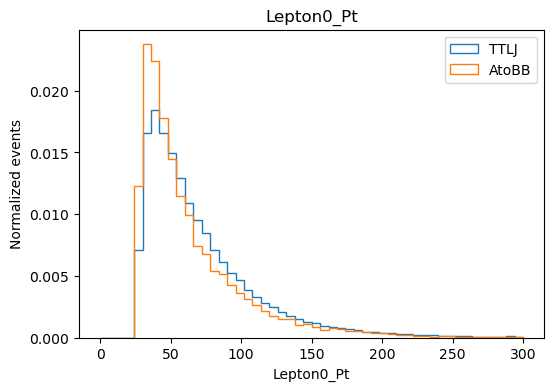

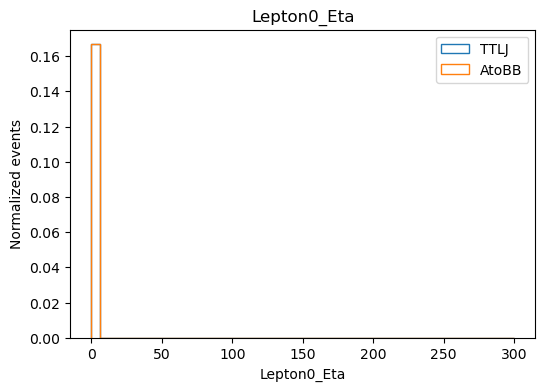

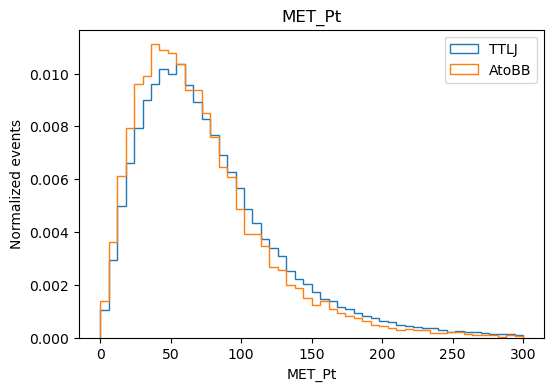

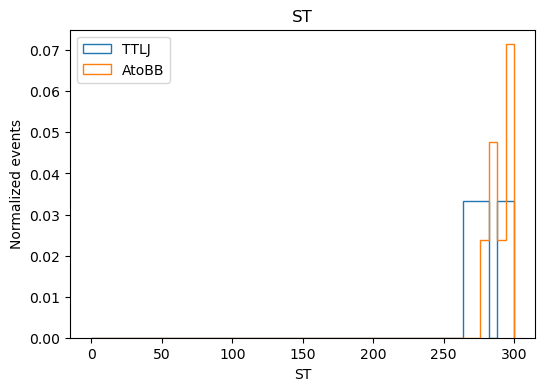

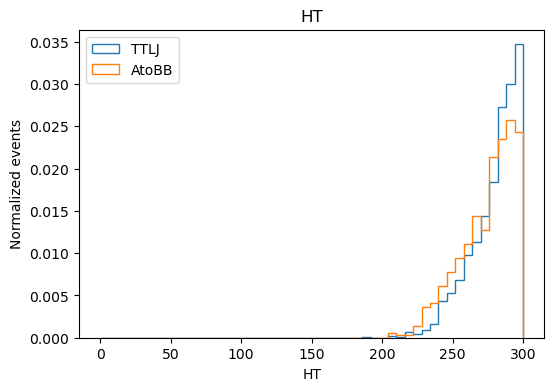

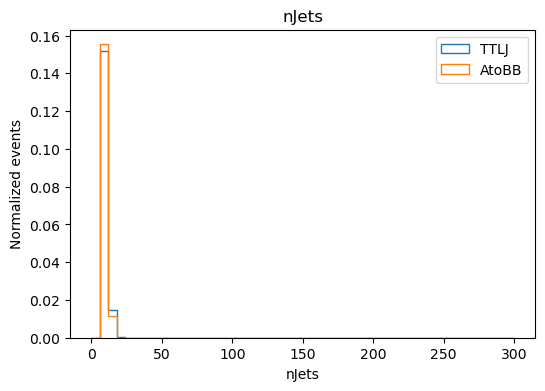

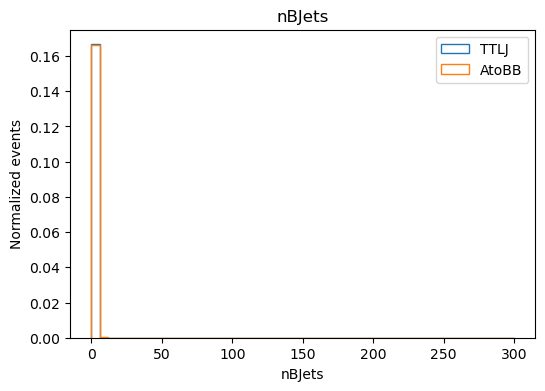

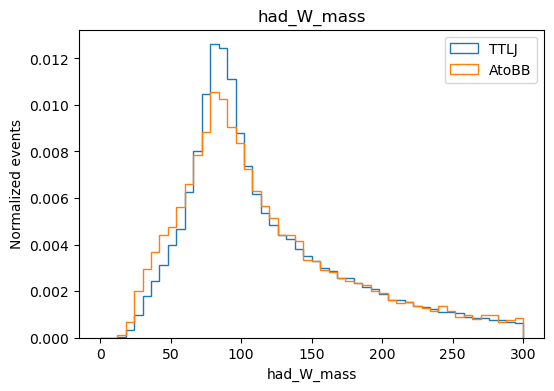

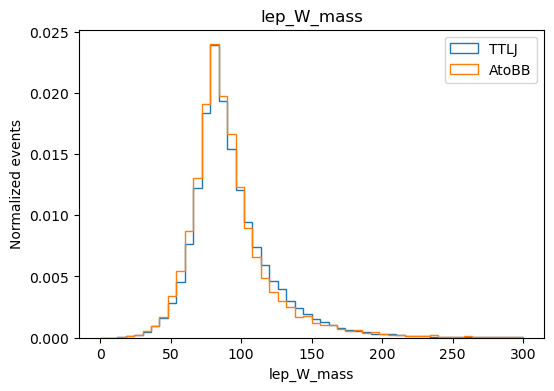

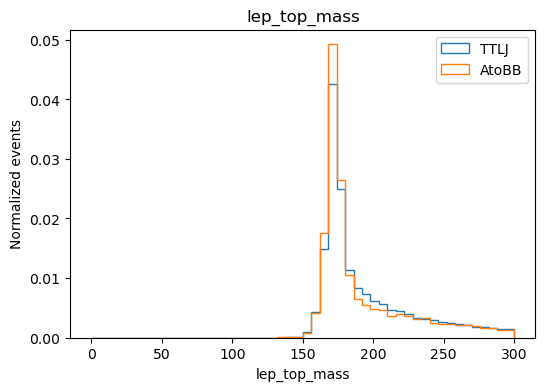

In [12]:
def plot_feature_shape(feature, bins=50, xmin=None, xmax=None):
    plt.figure(figsize=(6,4))

    plt.hist(
        df_bkg_clean[feature],
        bins=bins,
        range=(xmin, xmax) if xmin is not None else None,
        histtype="step",
        density=True,
        label="TTLJ"
        #label="AtoBB_filtered"
    )

    plt.hist(
        df_sig_clean[feature],
        bins=bins,
        range=(xmin, xmax) if xmin is not None else None,
        histtype="step",
        density=True,
        label="AtoBB"
    )

    plt.xlabel(feature)
    plt.ylabel("Normalized events")
    plt.legend()
    plt.title(feature)
    plt.show()

#for feat in [
#    "A_mass_best",
#    "bb_mass_closest_MA60_all",
#    "bb_mass_at_min_dr",
#    "bb_dr_min_all",
#    "A_dr_best",
#    "bscore_sum_top4",
#    "best_chi2",
#]:

for feat in [
    "Lepton0_Pt",
    "Lepton0_Eta",
    "MET_Pt",
    "ST",
    "HT",
    "nJets",
    "nBJets",
    "had_W_mass",
    "lep_W_mass",
    "lep_top_mass",
]:
    plot_feature_shape(feat, bins=50, xmin=0, xmax=300)

## 7. Quick sanity plots

These are not for final presentation, just to confirm signal/background shape differences.


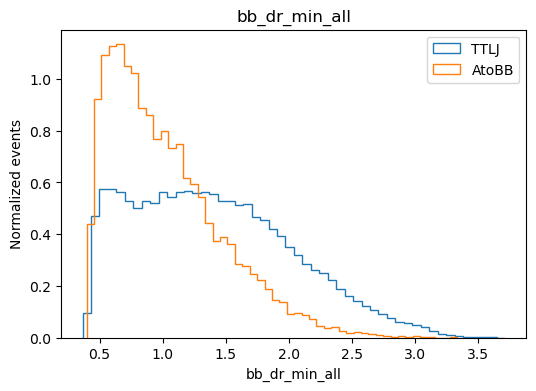

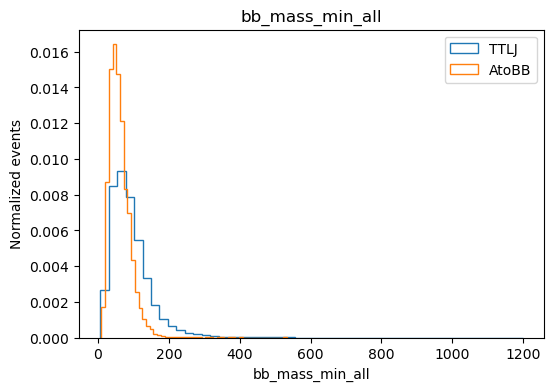

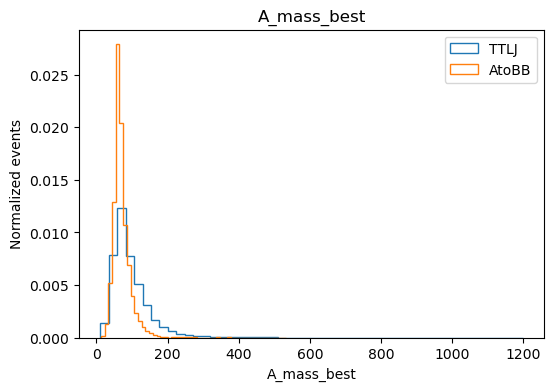

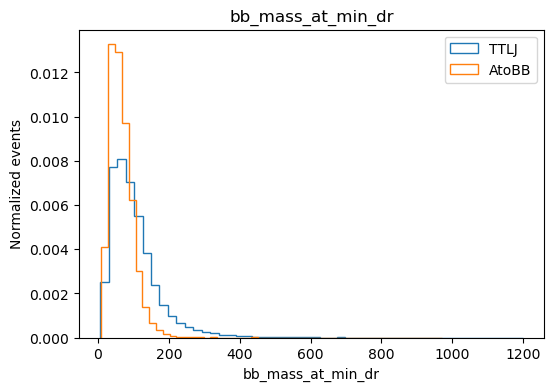

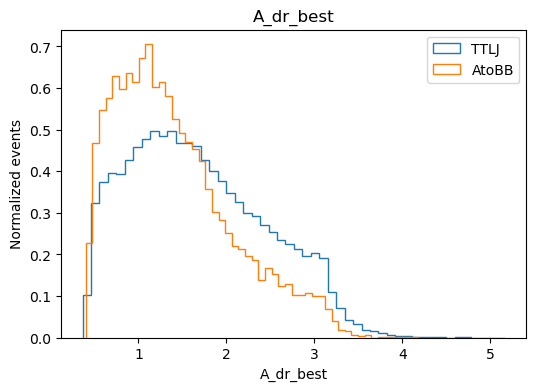

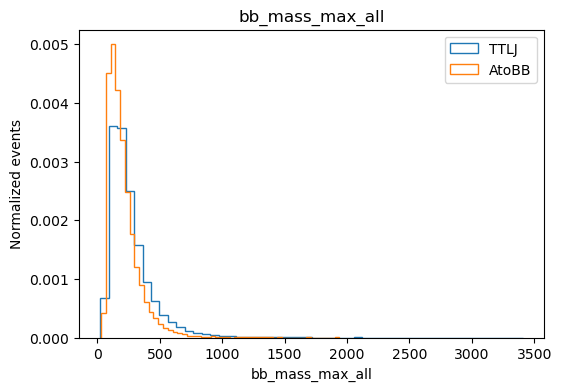

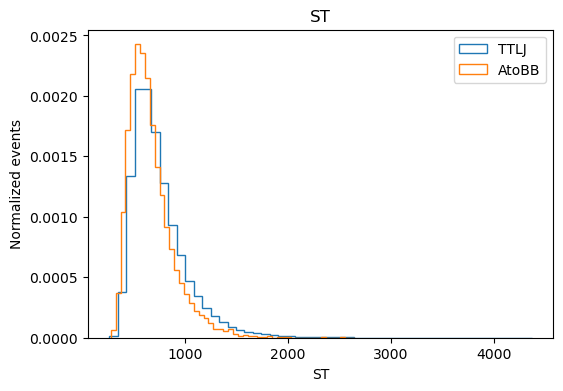

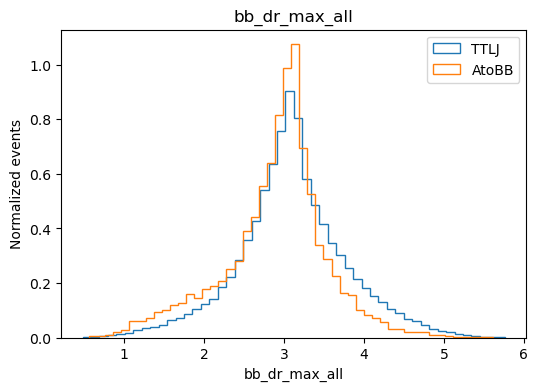

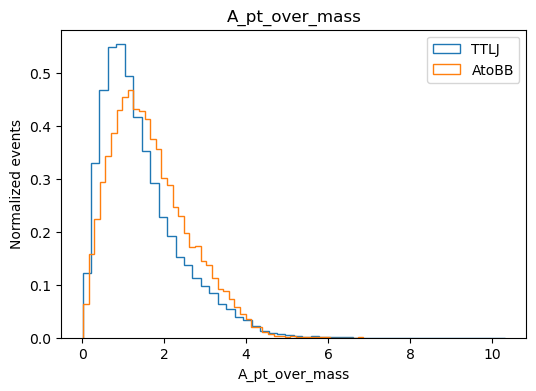

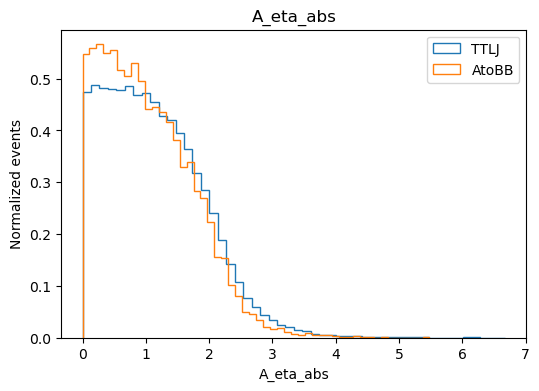

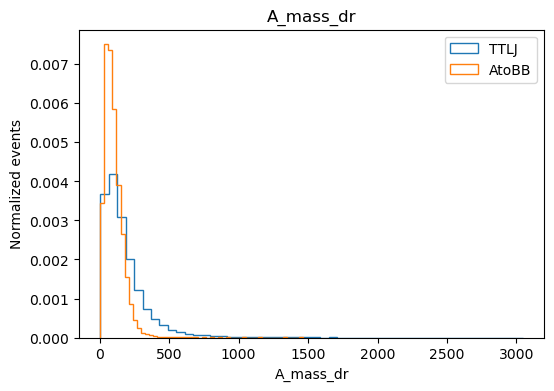

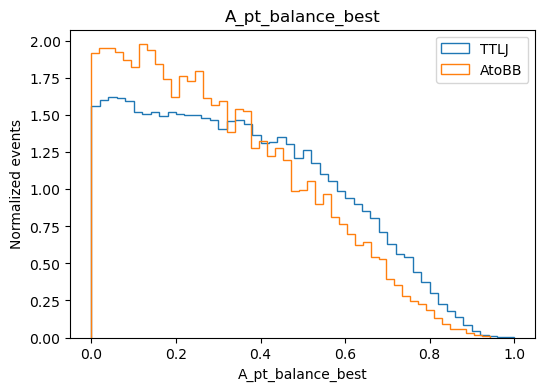

In [13]:
def plot_feature(sig, bkg, feature, bins=50, x_range=None, logy=False):
    plt.figure(figsize=(6, 4))
    plt.hist(bkg[feature], bins=bins, range=x_range, histtype="step", density=True, label="TTLJ")
    plt.hist(sig[feature], bins=bins, range=x_range, histtype="step", density=True, label="AtoBB")
    if logy:
        plt.yscale("log")
    plt.xlabel(feature)
    plt.ylabel("Normalized events")
    plt.title(feature)
    plt.legend()
    plt.show()

# for feat in ["nJets", "HT", "ST", "bb_mass_min_all", "bb_mass_max_all", "A_mass_best", "bb_dr_min_all", "bb_dr_max_all", "MET_Pt", "A_dr_best", "A_pt_best", "bscore_sum_top4", "best_chi2"]:
#     plot_feature(df_sig_clean, df_bkg_clean, feat, bins=50)

for feat in [    
    "bb_dr_min_all",
    "bb_mass_min_all",
    "A_mass_best",
    "bb_mass_at_min_dr",
#    "nBJets",
    "A_dr_best",
    "bb_mass_max_all",
    "ST",
    "bb_dr_max_all",
    "A_pt_over_mass",
    "A_eta_abs",
    "A_mass_dr",
    "A_pt_balance_best",
    
    ]:
    plot_feature(df_sig_clean, df_bkg_clean, feat, bins=50)

In [14]:
from sklearn.metrics import roc_auc_score

all_auc = []

for feat in FEATURES:

    sig = df_sig_clean[feat].to_numpy()
    bkg = df_bkg_clean[feat].to_numpy()

    y_true = np.concatenate([
        np.ones(len(sig)),
        np.zeros(len(bkg))
    ])

    score = np.concatenate([sig, bkg])

    auc = roc_auc_score(y_true, score)

    if auc < 0.5:
        auc = 1.0 - auc

    all_auc.append((feat, auc))

all_auc = sorted(all_auc, key=lambda x: x[1], reverse=True)

for feat, auc in all_auc:
    print(f"{feat:30s} {auc:.4f}")

bscore_sum_top4                0.7582
bscore_3rd                     0.7533
bb_mass_closest_MA60_all       0.6918
bb_dr_min_all                  0.6810
bb_mass_min_all                0.6785
bb_mass_at_min_dr              0.6693
A_bscore_min_best              0.6673
A_bscore_sum_best              0.6605
A_mass_dr                      0.6522
A_mass_best                    0.6511
nBJets                         0.6481
bscore_2nd                     0.6475
bb_mass_max_all                0.6170
bscore_sum                     0.6122
A_dr_best                      0.6047
ST                             0.5964
HT                             0.5883
A_pt_over_mass                 0.5829
bb_dr_max_all                  0.5764
bscore_max                     0.5744
Lepton0_Pt                     0.5681
A_pt_balance_best              0.5579
bb_mass_spread_all             0.5520
MET_Pt                         0.5413
A_eta_abs                      0.5374
lep_top_mass                   0.5359
nJets       

## 8. Train / validation split

Use stratified split so both train and validation contain signal and background.


In [15]:
df_all = pd.concat([df_sig_clean, df_bkg_clean], ignore_index=True)

train_df, val_df = train_test_split(
    df_all,
    test_size=0.2,
    random_state=42,
    stratify=df_all[LABEL_COL],
)

X_train = train_df[FEATURES].copy()
y_train = train_df[LABEL_COL].astype(int).copy()
w_train = train_df["ml_weight"].astype(float).copy()
# w_train = np.ones(len(train_df))

X_val = val_df[FEATURES].copy()
y_val = val_df[LABEL_COL].astype(int).copy()
w_val = val_df["ml_weight"].astype(float).copy()
# w_val = np.ones(len(val_df))

used_columns = list(X_train.columns)

if SCALER_TYPE == "standard":
    scaler = StandardScaler()
elif SCALER_TYPE == "minmax":
    scaler = MinMaxScaler()
elif SCALER_TYPE is None:
    scaler = None
else:
    raise ValueError(f"Unknown SCALER_TYPE = {SCALER_TYPE}")

if scaler is not None:
    X_train_np = scaler.fit_transform(X_train)
    X_val_np = scaler.transform(X_val)
else:
    X_train_np = X_train.to_numpy(dtype=np.float32)
    X_val_np = X_val.to_numpy(dtype=np.float32)

X_train = pd.DataFrame(X_train_np, columns=used_columns)
X_val = pd.DataFrame(X_val_np, columns=used_columns)

# ONNX/XGBoost conversion is safer with integer feature names.
X_train.columns = range(len(used_columns))
X_val.columns = range(len(used_columns))

print("Train label counts:")
print(y_train.value_counts())
print("Validation label counts:")
print(y_val.value_counts())
print("used columns:")
for i, c in enumerate(used_columns):
    print(f"  {i:02d}: {c}")




Train label counts:
label
0    74942
1    12075
Name: count, dtype: int64
Validation label counts:
label
0    18736
1     3019
Name: count, dtype: int64
used columns:
  00: HT
  01: ST
  02: MET_Pt
  03: nJets
  04: nJets_for_count
  05: nBJets
  06: Lepton0_Pt
  07: Lepton0_Eta
  08: A_mass_best
  09: A_dr_best
  10: A_pt_best
  11: A_bscore_sum_best
  12: A_bscore_min_best
  13: bb_mass_min_all
  14: bb_mass_max_all
  15: bb_mass_at_min_dr
  16: bb_mass_closest_MA60_all
  17: bb_mass_spread_all
  18: bb_dr_min_all
  19: bb_dr_max_all
  20: bscore_max
  21: bscore_2nd
  22: bscore_3rd
  23: bscore_sum
  24: bscore_sum_top4
  25: best_chi2
  26: had_W_mass
  27: had_top_mass
  28: lep_W_mass
  29: lep_top_mass
  30: A_pt_over_mass
  31: A_eta_abs
  32: A_mass_dr
  33: A_pt_balance_best


## 9. Train XGBoost model

This is a first-pass model. Tune `max_depth`, `eta`, and `num_boost_round` later.


In [16]:
dtrain = xgb.DMatrix(X_train, label=y_train, weight=w_train)
dval = xgb.DMatrix(X_val, label=y_val, weight=w_val)

params = {
    "max_depth": 4,
    "eta": 0.05,
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    # "min_child_weight": 10,
    # "lambda": 1.0,
    # "alpha": 0.5,
    "random_state": 42,
    "tree_method": "hist",
    # "scale_pos_weight": len(df_bkg_clean) / len(df_sig_clean)
}

evals_result = {}
model = xgb.train(
    params,
    dtrain,
    num_boost_round=NUM_BOOST_ROUND,
    evals=[(dtrain, "train"), (dval, "validation")],
    early_stopping_rounds=50,
    evals_result=evals_result,
    verbose_eval=50,
)

print("Finished training with num_boost_round =", NUM_BOOST_ROUND)
print("Final train logloss     =", evals_result["train"]["logloss"][-1])
print("Final validation logloss=", evals_result["validation"]["logloss"][-1])

[0]	train-logloss:0.67899	validation-logloss:0.67921
[50]	train-logloss:0.49602	validation-logloss:0.50433
[100]	train-logloss:0.47067	validation-logloss:0.48904
[150]	train-logloss:0.45684	validation-logloss:0.48380
[200]	train-logloss:0.44691	validation-logloss:0.48108
[250]	train-logloss:0.43880	validation-logloss:0.47964
[300]	train-logloss:0.43136	validation-logloss:0.47877
[350]	train-logloss:0.42442	validation-logloss:0.47806
[400]	train-logloss:0.41825	validation-logloss:0.47798
[450]	train-logloss:0.41196	validation-logloss:0.47785
[499]	train-logloss:0.40654	validation-logloss:0.47781
Finished training with num_boost_round = 500
Final train logloss     = 0.406540119708186
Final validation logloss= 0.4778140376118531


In [17]:
RUN_SCAN = False

if RUN_SCAN:
    scan_bkg_entries = [10000, 20000, 50000, 100000]
    scan_rounds = [20, 50, 100, 200, 300]
    scan_results = []

    for n_bkg in scan_bkg_entries:
        temp_bkg = df_bkg_clean.sample(n=min(n_bkg, len(df_bkg_clean)), random_state=42).copy()
        temp_all = pd.concat([df_sig_clean, temp_bkg], ignore_index=True)
        tr, va = train_test_split(temp_all, test_size=0.2, random_state=42, stratify=temp_all[LABEL_COL])

        Xtr_raw = tr[FEATURES].astype(float)
        Xva_raw = va[FEATURES].astype(float)
        ytr = tr[LABEL_COL].astype(int)
        yva = va[LABEL_COL].astype(int)
        wtr = tr["ml_weight"].astype(float)
        wva = va["ml_weight"].astype(float)

        scan_scaler = StandardScaler()
        Xtr = pd.DataFrame(scan_scaler.fit_transform(Xtr_raw), columns=range(len(FEATURES)))
        Xva = pd.DataFrame(scan_scaler.transform(Xva_raw), columns=range(len(FEATURES)))

        dtr = xgb.DMatrix(Xtr, label=ytr, weight=wtr)
        dva = xgb.DMatrix(Xva, label=yva, weight=wva)

        for n_round in scan_rounds:
            m = xgb.train(params, dtr, num_boost_round=n_round, evals=[(dva, "val")], verbose_eval=False)
            pred = m.predict(dva)
            fpr, tpr, _ = roc_curve(yva, pred, sample_weight=wva)
            auc_val = auc(fpr, tpr)
            scan_results.append({"n_bkg": n_bkg, "num_boost_round": n_round, "auc": auc_val})

    scan_df = pd.DataFrame(scan_results)
    display(scan_df)

## 10. Evaluation: ROC and score distributions


AUC = 0.8542736260523984


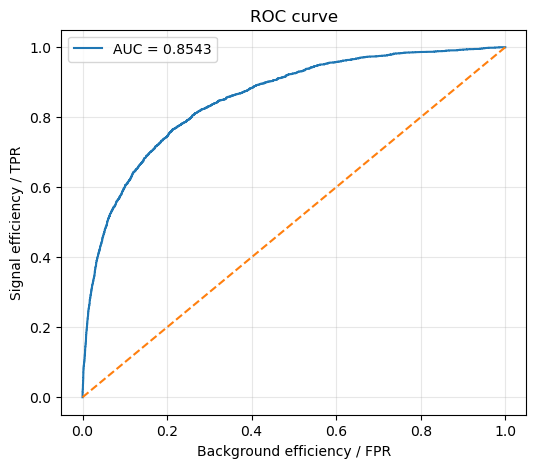

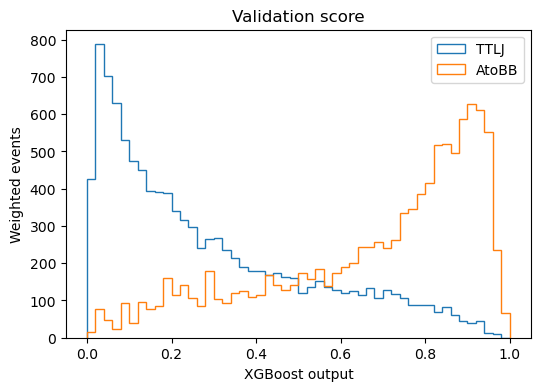

In [18]:
from sklearn.metrics import roc_curve, auc as sklearn_auc

y_pred = model.predict(dval)

fpr, tpr, thresholds = roc_curve(y_val, y_pred, sample_weight=w_val)
auc_val = sklearn_auc(fpr, tpr)
print("AUC =", auc_val)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_val:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Background efficiency / FPR")
plt.ylabel("Signal efficiency / TPR")
plt.title("ROC curve")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6,4))
plt.hist(y_pred[y_val.to_numpy() == 0], bins=50, range=(0,1), histtype="step", weights=w_val[y_val == 0], label="TTLJ")
plt.hist(y_pred[y_val.to_numpy() == 1], bins=50, range=(0,1), histtype="step", weights=w_val[y_val == 1], label="AtoBB")
plt.xlabel("XGBoost output")
plt.ylabel("Weighted events")
plt.legend()
plt.title("Validation score")
plt.show()


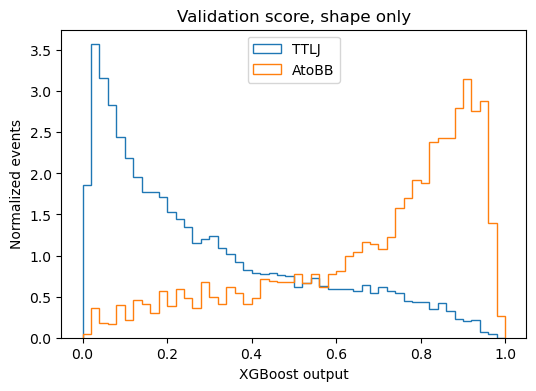

In [19]:
plt.figure(figsize=(6,4))
plt.hist(y_pred[y_val.to_numpy() == 0], bins=50, range=(0,1),
         histtype="step", density=True, label="TTLJ")
plt.hist(y_pred[y_val.to_numpy() == 1], bins=50, range=(0,1),
         histtype="step", density=True, label="AtoBB")
plt.xlabel("XGBoost output")
plt.ylabel("Normalized events")
plt.legend()
plt.title("Validation score, shape only")
plt.show()

## 11. Overtraining check

Compare train vs validation score shapes.


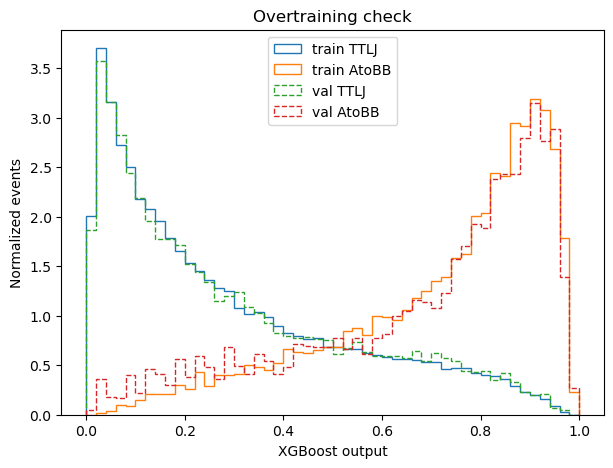

In [20]:
pred_train = model.predict(dtrain)
pred_val = model.predict(dval)

y_train_np = y_train.to_numpy()
y_val_np = y_val.to_numpy()
w_train_np = w_train.to_numpy()
w_val_np = w_val.to_numpy()

plt.figure(figsize=(7, 5))
plt.hist(pred_train[y_train_np == 0], bins=50, range=(0, 1), histtype="step", density=True, label="train TTLJ")
plt.hist(pred_train[y_train_np == 1], bins=50, range=(0, 1), histtype="step", density=True, label="train AtoBB")
plt.hist(pred_val[y_val_np == 0], bins=50, range=(0, 1), histtype="step", density=True, linestyle="--", label="val TTLJ")
plt.hist(pred_val[y_val_np == 1], bins=50, range=(0, 1), histtype="step", density=True, linestyle="--", label="val AtoBB")
plt.xlabel("XGBoost output")
plt.ylabel("Normalized events")
plt.title("Overtraining check")
plt.legend()
plt.show()


## 12. Feature importance


                     feature        gain
0            bscore_sum_top4  376.808228
1          bb_mass_at_min_dr  134.899765
2   bb_mass_closest_MA60_all  128.605362
3                 bscore_3rd  111.767776
4                  A_mass_dr   77.774368
5            bb_mass_max_all   73.068123
6                     nBJets   71.655396
7              bb_dr_min_all   61.005360
8                         ST   53.503349
9                A_mass_best   53.177303
10                Lepton0_Pt   44.458092
11           nJets_for_count   42.057903
12             bb_dr_max_all   36.945160
13              had_top_mass   34.047298
14        bb_mass_spread_all   33.575611
15           bb_mass_min_all   31.147781
16                had_W_mass   31.125519
17              lep_top_mass   28.692904
18         A_bscore_min_best   28.498671
19         A_pt_balance_best   28.481710
20                    MET_Pt   27.803288
21                bscore_max   26.713827
22                        HT   24.584068
23         A_bsc

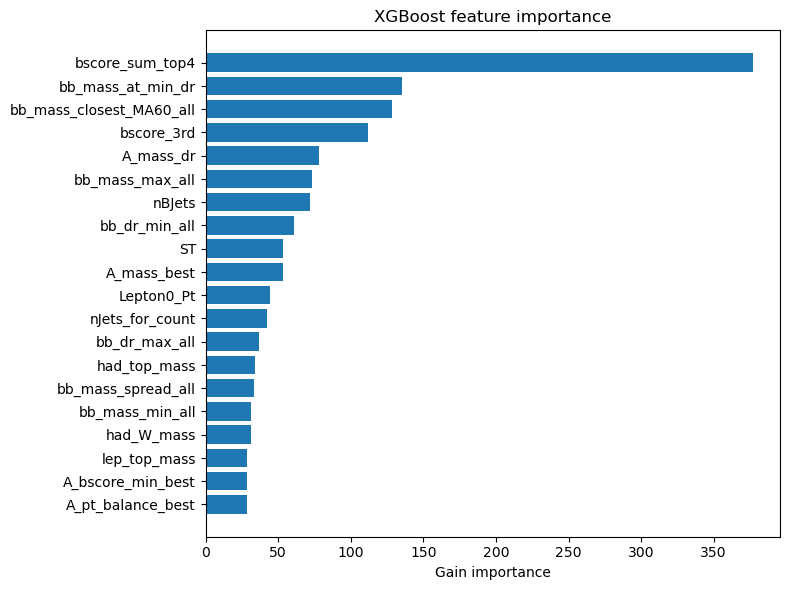

In [21]:
importance = model.get_score(importance_type="gain")
importance_named = []
for key, val in importance.items():
    # key is like f0, f1, ...
    idx = int(key[1:]) if key.startswith("f") else int(key)
    importance_named.append((used_columns[idx], val))
importance_named = sorted(importance_named, key=lambda x: x[1], reverse=True)

imp_df = pd.DataFrame(importance_named, columns=["feature", "gain"])
print(imp_df.head(30))

plt.figure(figsize=(8,6))
plot_df = imp_df.head(20).iloc[::-1]
plt.barh(plot_df["feature"], plot_df["gain"])
plt.xlabel("Gain importance")
plt.title("XGBoost feature importance")
plt.tight_layout()
plt.show()


In [22]:
PLOT_DIR = f"{MODEL_DIR}/scan_plots_0809"
os.makedirs(PLOT_DIR, exist_ok=True)
from sklearn.metrics import roc_curve, auc as sklearn_auc


def save_current_plots(tag):
    # 1. ROC
    y_pred = model.predict(dval)
    fpr, tpr, thresholds = roc_curve(y_val, y_pred, sample_weight=w_val)
    auc_val = sklearn_auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {auc_val:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("Background efficiency / FPR")
    plt.ylabel("Signal efficiency / TPR")
    plt.title(f"ROC curve: {tag}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/roc_{tag}.png", dpi=150)
    plt.close()

    # 2. validation score
    plt.figure(figsize=(6, 4))
    plt.hist(y_pred[y_val.to_numpy() == 0], bins=50, range=(0, 1),
             histtype="step", density=True, weights=w_val.to_numpy()[y_val.to_numpy() == 0],
             label="TTLJ")
    plt.hist(y_pred[y_val.to_numpy() == 1], bins=50, range=(0, 1),
             histtype="step", density=True, weights=w_val.to_numpy()[y_val.to_numpy() == 1],
             label="AtoBB")
    plt.xlabel("XGBoost output")
    plt.ylabel("Normalized events")
    plt.title(f"Validation score: {tag}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/score_{tag}.png", dpi=150)
    plt.close()

    # 2.1. shape only
    plt.figure(figsize=(6,4))
    plt.hist(y_pred[y_val.to_numpy() == 0], bins=50, range=(0,1),
             histtype="step", density=True, label="TTLJ")
    plt.hist(y_pred[y_val.to_numpy() == 1], bins=50, range=(0,1),
             histtype="step", density=True, label="AtoBB")
    plt.xlabel("XGBoost output")
    plt.ylabel("Normalized events")
    plt.legend()
    plt.title("Validation score, shape only")
    plt.savefig(f"{PLOT_DIR}/score_shape_{tag}.png", dpi=150)
    plt.close() 

    # 3. overtraining check
    pred_train = model.predict(dtrain)
    pred_val = model.predict(dval)

    y_train_np = y_train.to_numpy()
    y_val_np = y_val.to_numpy()
    w_train_np = w_train.to_numpy()
    w_val_np = w_val.to_numpy()

    plt.figure(figsize=(7, 5))
    plt.hist(pred_train[y_train_np == 0], bins=50, range=(0, 1), histtype="step",
             density=True, weights=w_train_np[y_train_np == 0], label="train TTLJ")
    plt.hist(pred_train[y_train_np == 1], bins=50, range=(0, 1), histtype="step",
             density=True, weights=w_train_np[y_train_np == 1], label="train AtoBB")
    plt.hist(pred_val[y_val_np == 0], bins=50, range=(0, 1), histtype="step",
             density=True, linestyle="--", weights=w_val_np[y_val_np == 0], label="val TTLJ")
    plt.hist(pred_val[y_val_np == 1], bins=50, range=(0, 1), histtype="step",
             density=True, linestyle="--", weights=w_val_np[y_val_np == 1], label="val AtoBB")
    plt.xlabel("XGBoost output")
    plt.ylabel("Normalized events")
    plt.title(f"Overtraining check: {tag}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/overtraining_{tag}.png", dpi=150)
    plt.close()

    # 4. feature importance
    importance = model.get_score(importance_type="gain")
    importance_named = []
    for key, val in importance.items():
        # key is like f0, f1, ...
        idx = int(key[1:]) if key.startswith("f") else int(key)
        importance_named.append((used_columns[idx], val))
    importance_named = sorted(importance_named, key=lambda x: x[1], reverse=True)

    imp_df = pd.DataFrame(importance_named, columns=["feature", "gain"])
    print(imp_df.head(30))

    plt.figure(figsize=(8,6))
    plot_df = imp_df.head(20).iloc[::-1]
    plt.barh(plot_df["feature"], plot_df["gain"])
    plt.xlabel("Gain importance")
    plt.title("XGBoost feature importance")
    plt.tight_layout()
    plt.savefig(f"{PLOT_DIR}/importance_{tag}.png", dpi=150)
    plt.close()



tag = f"nbkg{N_BKG}_boost{NUM_BOOST_ROUND}"
auc_val = save_current_plots(tag)
print("Saved plots with tag:", tag, "AUC:", auc_val)

                     feature        gain
0            bscore_sum_top4  376.808228
1          bb_mass_at_min_dr  134.899765
2   bb_mass_closest_MA60_all  128.605362
3                 bscore_3rd  111.767776
4                  A_mass_dr   77.774368
5            bb_mass_max_all   73.068123
6                     nBJets   71.655396
7              bb_dr_min_all   61.005360
8                         ST   53.503349
9                A_mass_best   53.177303
10                Lepton0_Pt   44.458092
11           nJets_for_count   42.057903
12             bb_dr_max_all   36.945160
13              had_top_mass   34.047298
14        bb_mass_spread_all   33.575611
15           bb_mass_min_all   31.147781
16                had_W_mass   31.125519
17              lep_top_mass   28.692904
18         A_bscore_min_best   28.498671
19         A_pt_balance_best   28.481710
20                    MET_Pt   27.803288
21                bscore_max   26.713827
22                        HT   24.584068
23         A_bsc

## 13. Export to ONNX

This creates `xgboost_atobb_ttlJ.onnx` and a JSON file containing the exact feature order.

The C++ inference input vector **must use this exact order**.


In [ ]:
initial_type = [("input", FloatTensorType([None, len(used_columns)]))]
onnx_model = convert_xgboost_booster(model, initial_types=initial_type, target_opset=12)
onnx.save_model(onnx_model, ONNX_PATH)

metadata = {
    "features": used_columns,
    "feature_indices": {name: i for i, name in enumerate(used_columns)},
    "scaler_type": SCALER_TYPE,
    "n_bkg": N_BKG,
    "num_boost_round": NUM_BOOST_ROUND,
    "params": params,
    "auc": float(auc_val),
}

with open(FEATURE_JSON_PATH, "w") as f:
    json.dump(metadata, f, indent=4)

if scaler is not None:
    with open(SCALER_PKL_PATH, "wb") as f:
        pickle.dump(scaler, f)

    scaler_json = {
        "scaler_type": SCALER_TYPE,
        "features": used_columns,
    }
    if SCALER_TYPE == "standard":
        scaler_json["mean"] = scaler.mean_.tolist()
        scaler_json["scale"] = scaler.scale_.tolist()
    elif SCALER_TYPE == "minmax":
        scaler_json["min"] = scaler.min_.tolist()
        scaler_json["scale"] = scaler.scale_.tolist()
        scaler_json["data_min"] = scaler.data_min_.tolist()
        scaler_json["data_max"] = scaler.data_max_.tolist()

    with open(SCALER_JSON_PATH, "w") as f:
        json.dump(scaler_json, f, indent=4)

print("Saved ONNX:", ONNX_PATH)
print("Saved feature metadata:", FEATURE_JSON_PATH)
print("Saved scaler json:", SCALER_JSON_PATH)
print("Saved scaler pickle:", SCALER_PKL_PATH)

## 14. Validate ONNX output against XGBoost output

This checks that the exported ONNX model gives the same score as the original XGBoost model.


In [ ]:
import onnxruntime as ort

sess = ort.InferenceSession(ONNX_PATH, providers=["CPUExecutionProvider"])
print("ONNX inputs:", sess.get_inputs())
print("ONNX outputs:", sess.get_outputs())

X_val_np = X_val.to_numpy(dtype=np.float32)
onnx_outputs = sess.run(None, {"input": X_val_np})

# For binary:logistic conversion, output name/shape can differ by package version.
# Print shapes first.
for i, out in enumerate(onnx_outputs):
    print(i, type(out), getattr(out, "shape", None))

# Try common cases.
y_pred_onnx = None
if len(onnx_outputs) == 1:
    y_pred_onnx = np.asarray(onnx_outputs[0]).reshape(-1)
else:
    # Often: labels, probabilities. probabilities may be array or list of dicts.
    prob = onnx_outputs[-1]
    if isinstance(prob, list):
        y_pred_onnx = np.array([p[1] if 1 in p else p.get("1") for p in prob], dtype=float)
    else:
        prob = np.asarray(prob)
        if prob.ndim == 2 and prob.shape[1] >= 2:
            y_pred_onnx = prob[:, 1]
        else:
            y_pred_onnx = prob.reshape(-1)

print("ONNX pred ready:", y_pred_onnx.shape)
print("max |xgb - onnx| =", np.max(np.abs(y_pred - y_pred_onnx)))

plt.figure(figsize=(6,4))
plt.hist(np.abs(y_pred - y_pred_onnx), bins=50, histtype="step")
plt.xlabel("|XGBoost - ONNX|")
plt.ylabel("Events")
plt.title("ONNX validation")
plt.show()


## 15. C++ inference note

For SKNano C++ inference, use the exact feature order saved in `xgboost_atobb_ttlJ_features.json`.

The input shape should be:

```cpp
input_shape_xgboost["input"] = {1, N_FEATURES};
```

where `N_FEATURES` is printed above.
